**Jack Dai**

Spring 2026

CS 251 / 252: Data Analysis and Visualization

Project 5: Principal Component Analysis


In [11]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

import pca

plt.style.use(['seaborn-v0_8-colorblind', 'seaborn-v0_8-darkgrid'])
plt.rcParams.update({'font.size': 20})

np.set_printoptions(suppress=True, precision=5, legacy='1.25')

# Automatically reload external modules
%load_ext autoreload
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


## Task 4: Eigenfaces — PCA on face images

This task explores the Eigenface algorithm, which involves performing PCA on images of faces. Here is a [link](https://sites.cs.ucsb.edu/~mturk/Papers/jcn.pdf) to original paper. Here, we will apply the algorithm to ~16,000 images of cat faces to discover and visualize important characteristics that account for much of the variation across the feline dataset.

_Reference:_ M. Turk; A. Pentland (1991). "Eigenfaces for recognition" (PDF). _Journal of Cognitive Neuroscience_. 3 (1): 71–86.


### 4a. Load in cat faces dataset

Run the following cell to load in the cat face images.


In [12]:
cat_imgs = np.load('data/cats.npy')

print(f'There are {len(cat_imgs)} faces. There should be 15747.')
print(f'Shape of images is are {cat_imgs.shape} faces. It should be (15747, 64, 64).')


There are 15747 faces. There should be 15747.
Shape of images is are (15747, 64, 64) faces. It should be (15747, 64, 64).


### 4b. Look at the face data

In the cell below, fill in the function to create a 5x6 subplots grid of plots (_5 rows, 6 columns_). In each plot, show one of the first 30 images in the dataset. For the title of the plot, indicate the cat's sample number (Cat 0, Cat 1, etc.). For showing the image, use [imshow](https://matplotlib.org/stable/api/_as_gen/matplotlib.pyplot.imshow.html):

Run the function to create the plot of the faces below.


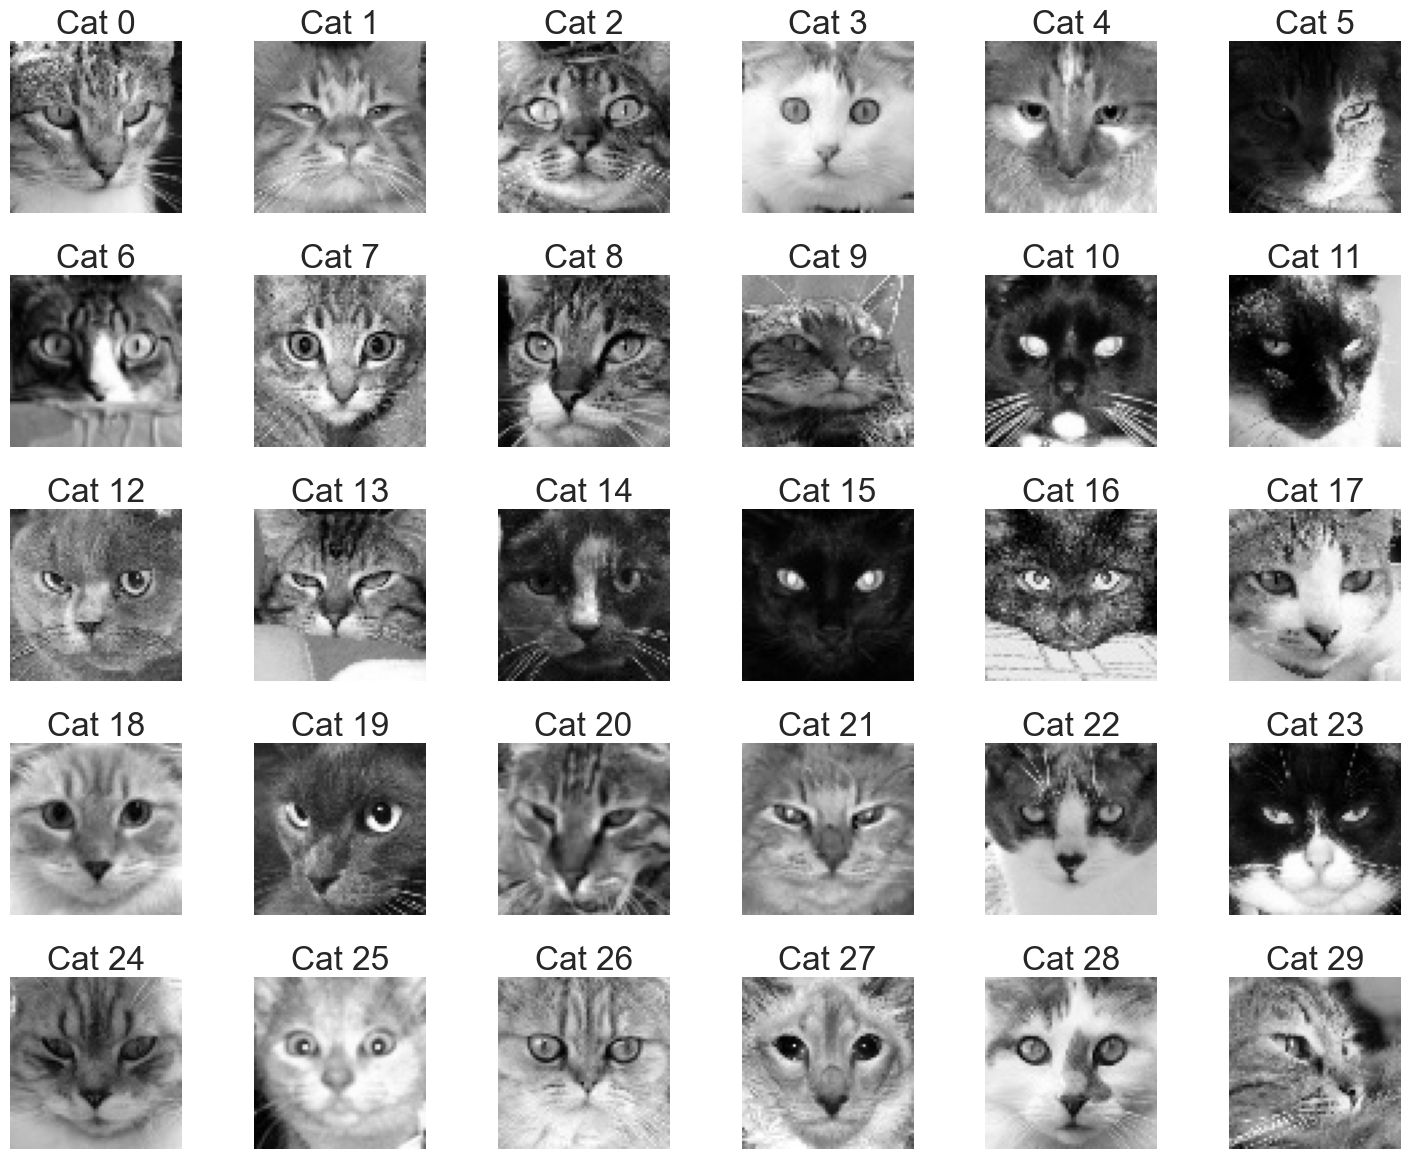

In [13]:
def face_plot(face_imgs):
    '''Creates a grid of grayscale face images.
    
    Parameters:
    -----------
    face_imgs: ndarray. shape=(N, img_y, img_x).
        Grayscale images to show.

    NOTE:
    - When you call `imshow`, add this optional parameter (otherwise faces will look ghastly): `cmap=plt.get_cmap('gray')`
    - Turn off the x and y ticks (they just add clutter).
    '''
    rows, cols = 5, 6
    fig, axs = plt.subplots(rows, cols, figsize=(15, 12))
    for i, ax in enumerate(axs.ravel()):
        if i < len(face_imgs):
            ax.imshow(face_imgs[i], cmap=plt.get_cmap('gray'))
            ax.set_title(f'Cat {i}')
        ax.set_xticks([])
        ax.set_yticks([])
    plt.tight_layout()
    plt.show()

face_plot(cat_imgs[:30])

### 4c. Visualize the "mean face"

Take the mean face image across the dataset and show it below.

**Note:** Use the same `cmap` parameter as above and turn off x and y tick marks.


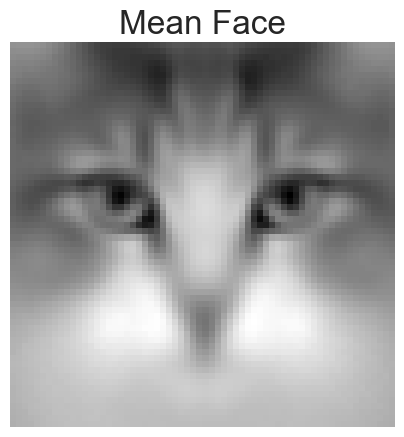

In [14]:
# YOUR CODE HERE
mean_face = np.mean(cat_imgs, axis=0)
plt.figure(figsize=(5, 5))
plt.imshow(mean_face, cmap=plt.get_cmap('gray'))
plt.title('Mean Face')
plt.xticks([])
plt.yticks([])
plt.show()

### 4d. Preprocess face data

In the dataset, each face is a sample and each pixel is a variable. Currently, the face data has shape = `(15747, 64, 64)` or $N = 15747$ samples and $M = 64*64 = 4096$ pixels. To run PCA, we'll need to \"unravel\" each row of pixels and glue them into one big vector so that the shape = `(15747, 64*64)` = `(15747, 4096)`. This will make a standard matrix and should work with your PCA code.

In the following cell, reshape the face data **without hardcoding** ANY of (15747, 64\*64)!


In [15]:
# Your reshape code here
num_imgs, img_h, img_w = cat_imgs.shape
cat_imgs_vec = cat_imgs.reshape(num_imgs, img_h * img_w)
print(f'Your reshaped face images have shape={cat_imgs_vec.shape} and it should be (15747, 4096).')

Your reshaped face images have shape=(15747, 4096) and it should be (15747, 4096).


### 4e. Perform PCA on preprocessed face data

Create pandas DataFrame object that holds the face data then run PCA on the face dataset. The header names of consecutive integers `0, 1, ..., 4095` are fine. For the `vars` parameter in the `fit` method, pass in a Python list of ints (`0, 1, ..., 4095`).

**Notes:**

- This is not a "toy" dataset so it may take a few minutes for the PCA to finish computing.
- Use the python `time` module (i.e. `import time`) to time how long the `pca` method takes to finish processing the data, then print out the time elapsed below. If this takes more than a few minutes, something probably is wrong.


In [16]:
# YOUR CODE HERE
import time

cat_face_df = pd.DataFrame(cat_imgs_vec, columns=list(range(cat_imgs_vec.shape[1])))
cat_face_pca = pca.PCA(cat_face_df)
cat_vars = list(cat_face_df.columns)

start_time = time.time()
cat_face_pca.fit(cat_vars, normalize_dataset=False)
elapsed_sec = time.time() - start_time

In [17]:
# YOUR CODE HERE
print(f'PCA elapsed time: {elapsed_sec:.2f} seconds')
print(f'Number of PCs: {len(cat_face_pca.get_eigenvalues())}')
print(f'First 5 cumulative variance values: {cat_face_pca.get_cum_var()[:5]}')

PCA elapsed time: 52.15 seconds
Number of PCs: 4096
First 5 cumulative variance values: [0.3526635332185464, 0.45707888982012274, 0.5469558092794781, 0.6020347456276829, 0.6309262994749917]


### 4f. Make face PCA elbow plot

Make an elbow plot of the PCA results. Show **only show a reasonable number of PCs** to focus on the curve before it plateaus.


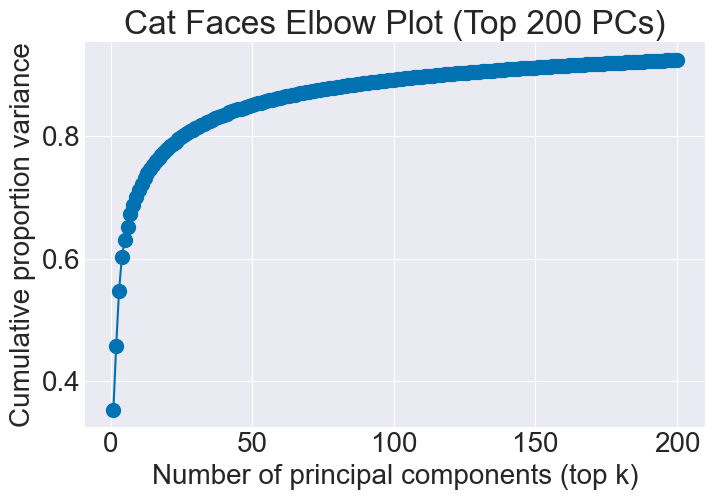

In [19]:
# YOUR CODE HERE
plt.figure(figsize=(8, 5))
cat_face_pca.elbow_plot(num_pcs_to_keep=200)
plt.title('Cat Faces Elbow Plot (Top 200 PCs)')
plt.show()

### 4g. Reconstruct faces using the principal components

Use your elbow plot to find the number of top principal components required to _approximately_ explain the following cumulative proportion of the variance:

- 50%
- 70%
- 90%
- 97%

Outline of the general process:

1. For each of the above number of PCs, project them back onto the original data space.
2. Write then use the below `make_imgs` function to convert the projected data back to image shapes `(15747, 64, 64)`.
3. Use `face_plot` to plot the reconstructed 1st 30 faces with each of the variance numbers above.

**There should be 4 5x6 plots below**


In [21]:
# YOUR CODE HERE
cum_var = cat_face_pca.get_cum_var()

def pcs_for_var_threshold(cum_var_vals, threshold):
    for i, val in enumerate(cum_var_vals):
        if val >= threshold:
            return i + 1
    return len(cum_var_vals)

k_50 = pcs_for_var_threshold(cum_var, 0.50)
k_70 = pcs_for_var_threshold(cum_var, 0.70)
k_90 = pcs_for_var_threshold(cum_var, 0.90)
k_97 = pcs_for_var_threshold(cum_var, 0.97)

print(f'PCs for 50% variance: {k_50}')
print(f'PCs for 70% variance: {k_70}')
print(f'PCs for 90% variance: {k_90}')
print(f'PCs for 97% variance: {k_97}')

PCs for 50% variance: 3
PCs for 70% variance: 9
PCs for 90% variance: 116
PCs for 97% variance: 766


In [23]:
def make_imgs(reconstucted_imgs):
    '''Inflates a 1D feature vector representation of images into 2D images for plotting.
    Assumes square images
    
    Parameters:
    -----------
    reconstucted_imgs: ndarray. shape=(N, img_y*img_x)
        1D vector representation of each image
    
    Returns:
    -----------
    ndarray. shape=(N, img_y, img_x)
        The images inflated into 2D
    '''
    n_samples, n_features = reconstucted_imgs.shape
    side_len = int(np.sqrt(n_features))
    return reconstucted_imgs.reshape(n_samples, side_len, side_len)


#### 50% variance face grid


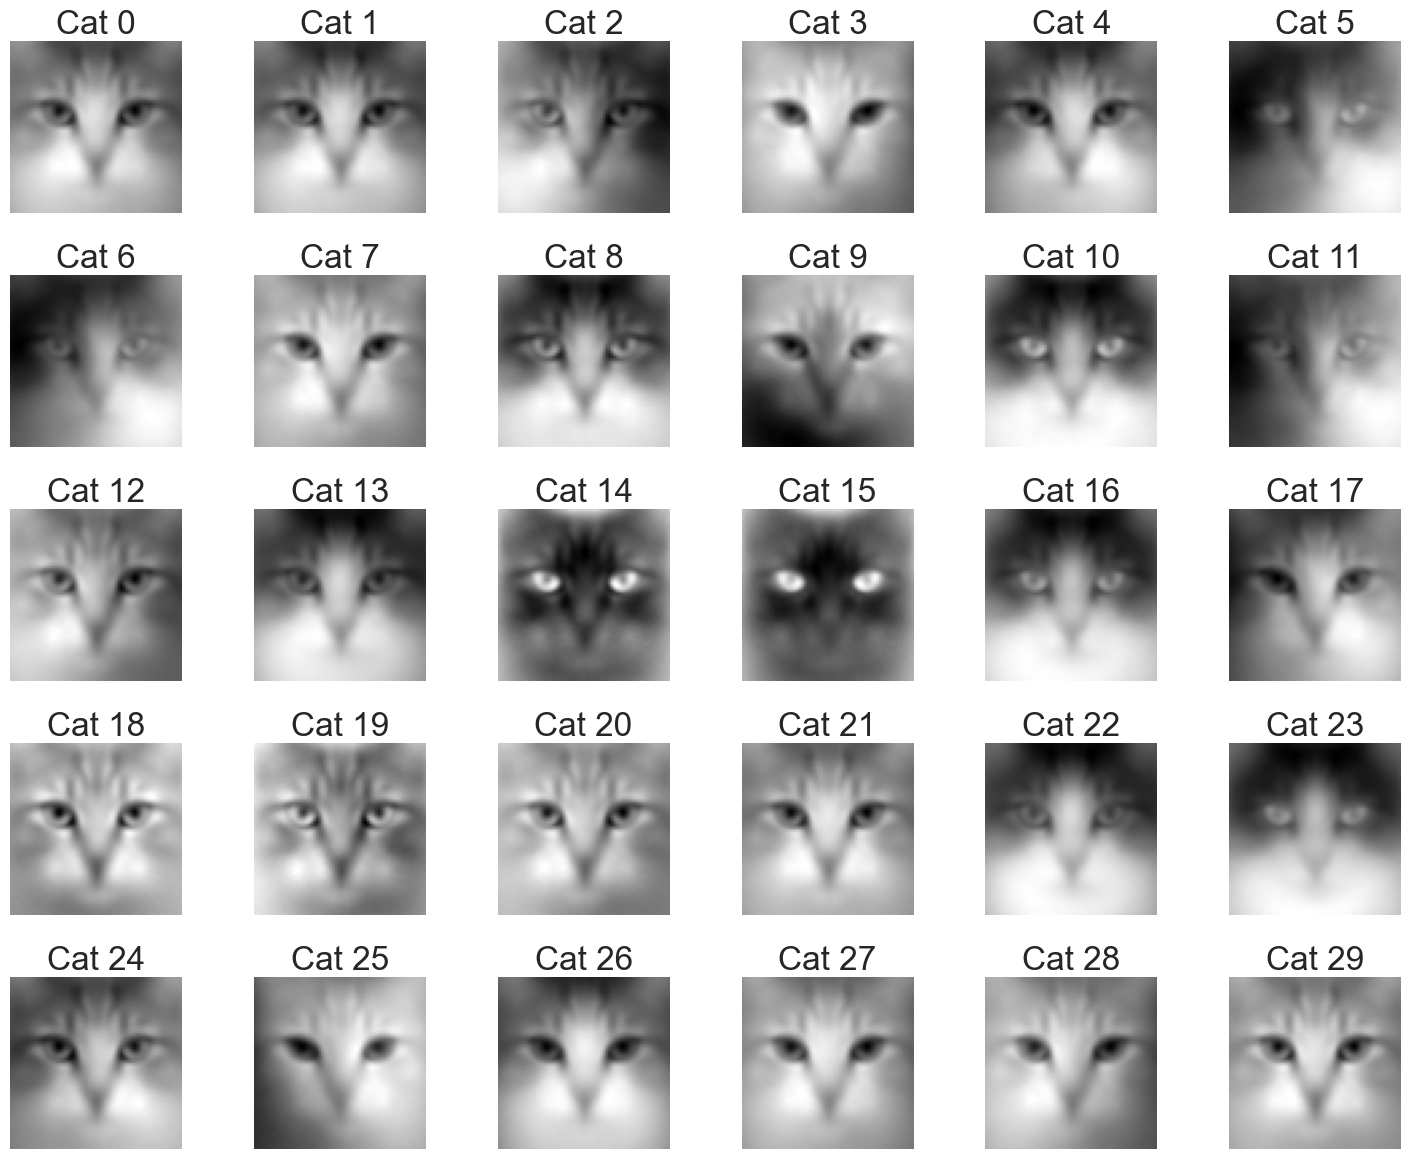

In [25]:
# YOUR CODE HERE
recon_50 = cat_face_pca.pca_then_project_back(k_50)
recon_50_imgs = make_imgs(recon_50[:30])
face_plot(recon_50_imgs)

#### 70% variance face grid


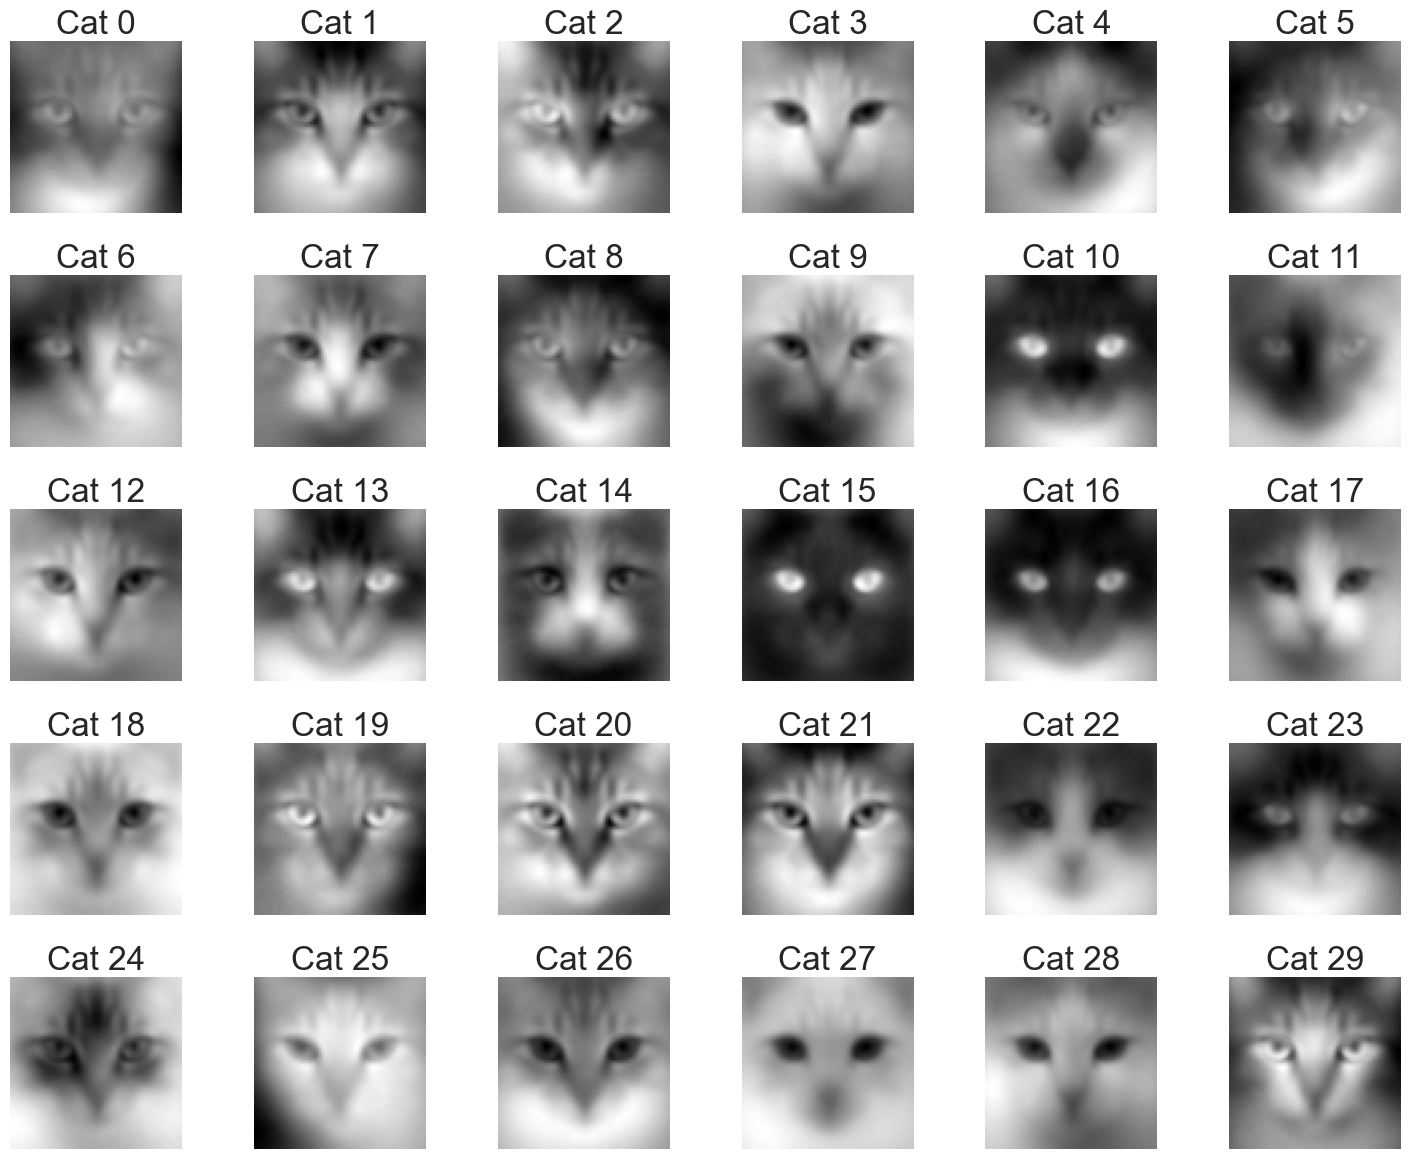

In [27]:
# YOUR CODE HERE
recon_70 = cat_face_pca.pca_then_project_back(k_70)
recon_70_imgs = make_imgs(recon_70[:30])
face_plot(recon_70_imgs)

#### 90% variance face grid


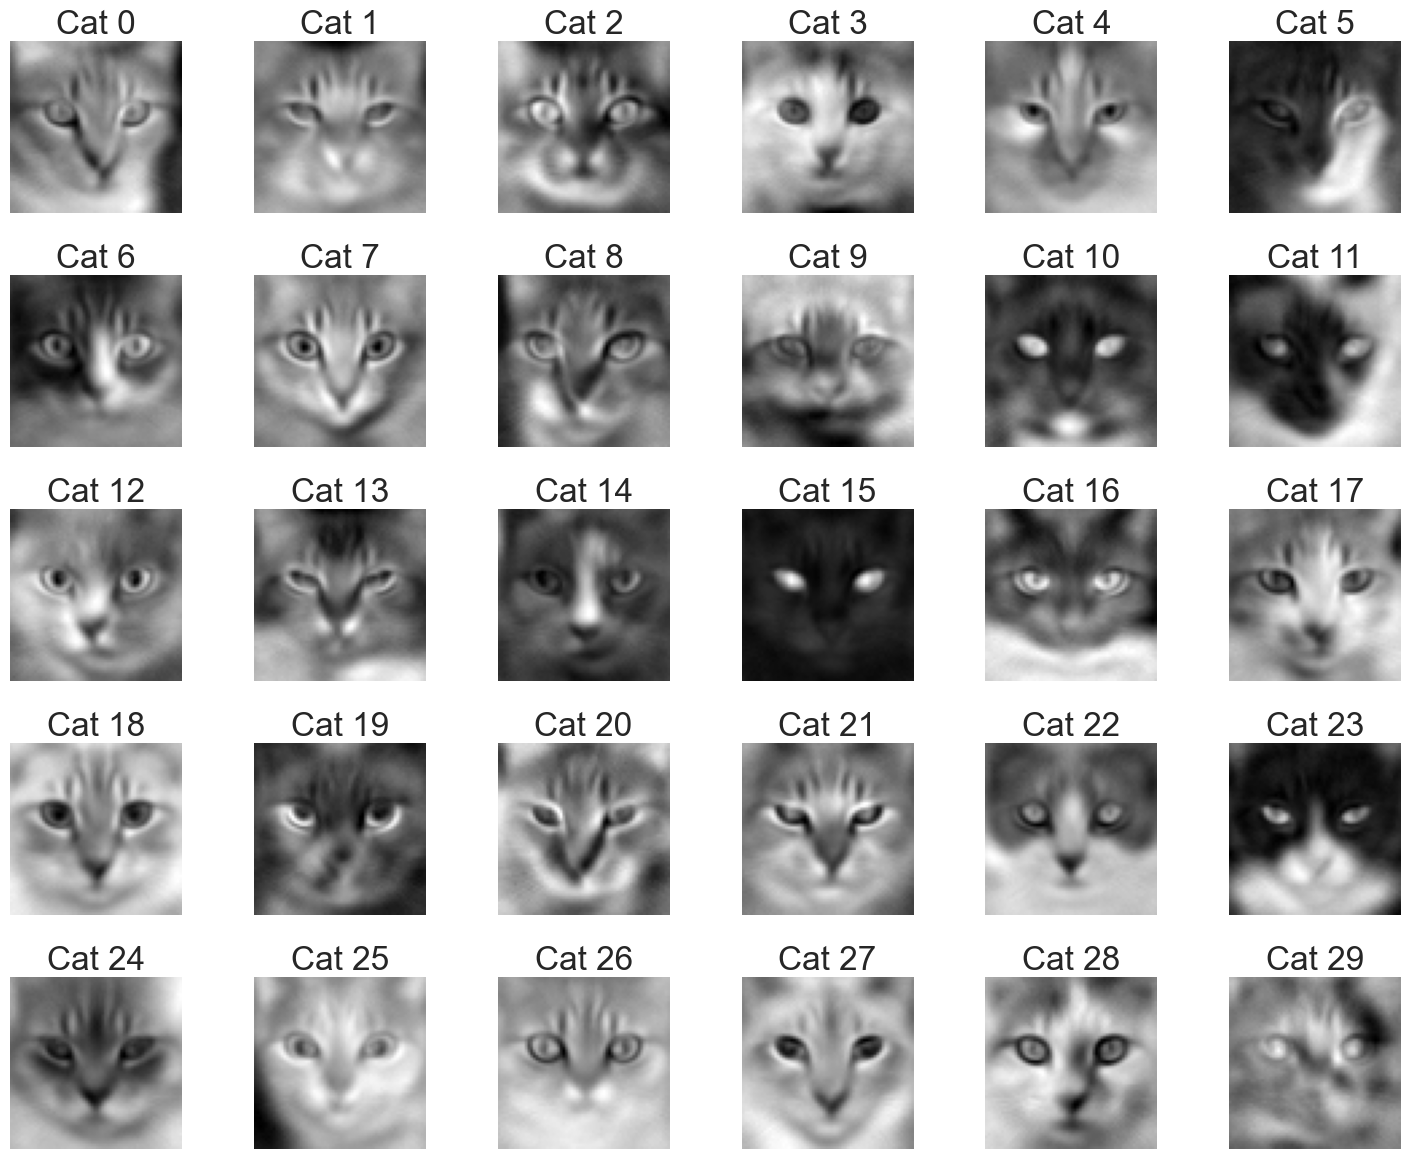

In [29]:
# YOUR CODE HERE
recon_90 = cat_face_pca.pca_then_project_back(k_90)
recon_90_imgs = make_imgs(recon_90[:30])
face_plot(recon_90_imgs)

#### 97% variance face grid


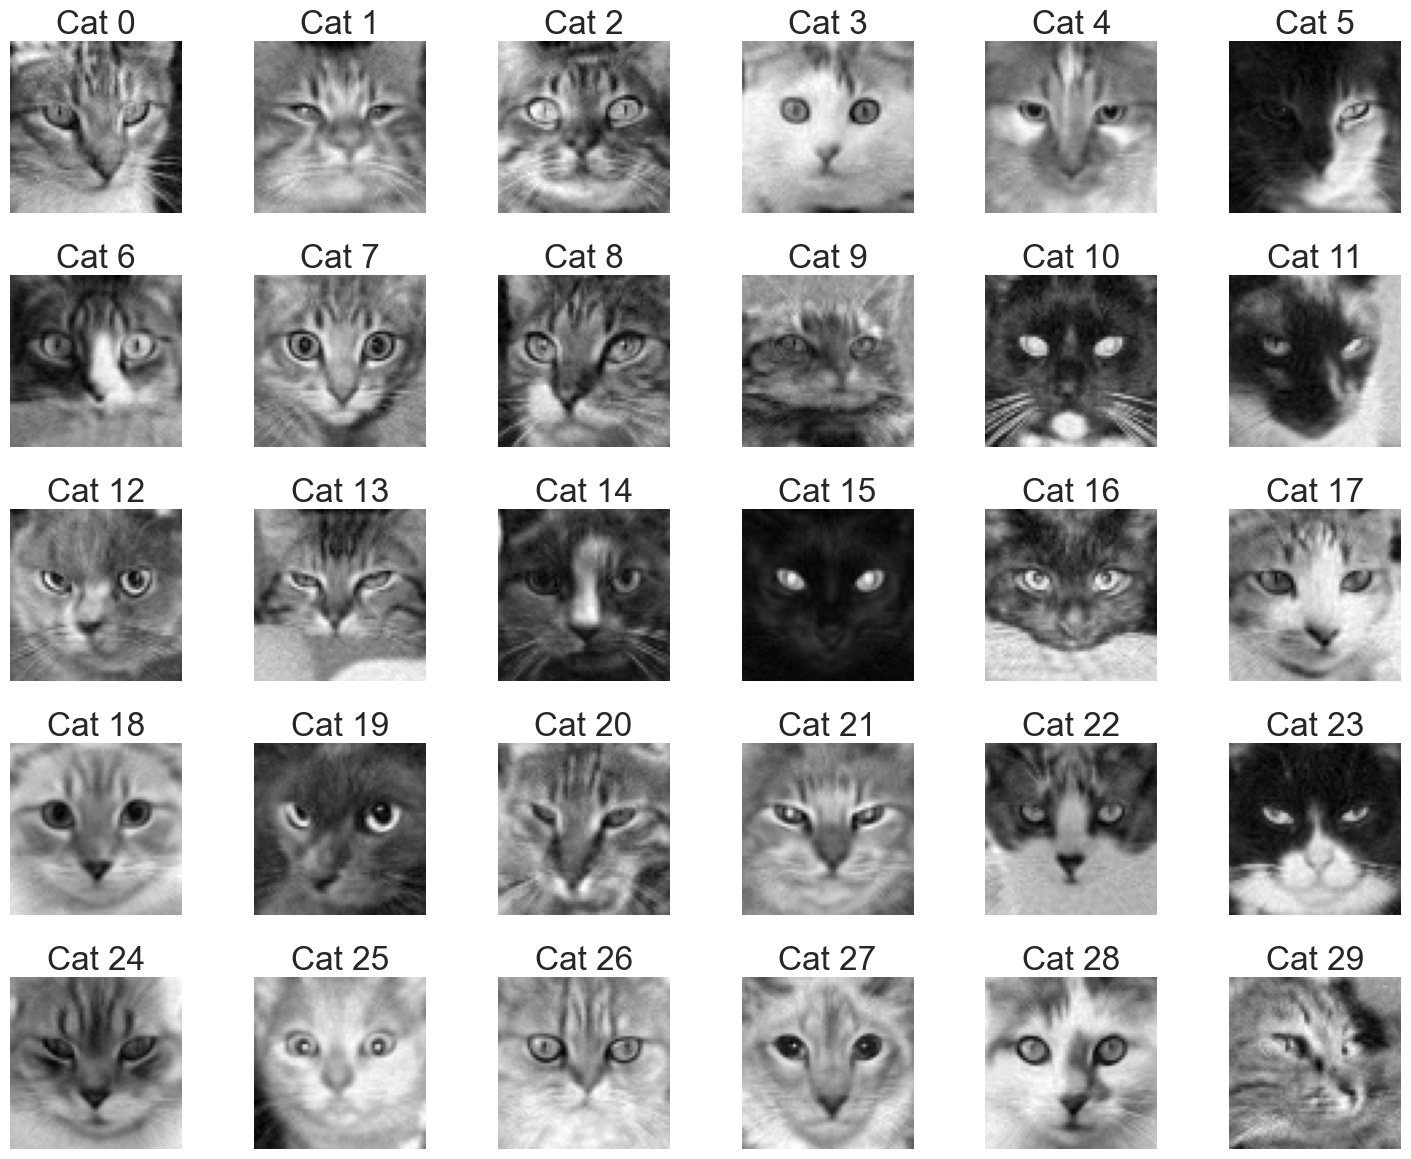

In [31]:
# YOUR CODE HERE
recon_97 = cat_face_pca.pca_then_project_back(k_97)
recon_97_imgs = make_imgs(recon_97[:30])
face_plot(recon_97_imgs)

### 4h. Questions

**Question 12:** Pick one of the faces to focus on. Describe the transformation that unfolds over the course of the 4 plots. Please be specific.


**Answer 12:**


Focusing on **Cat 0**, the reconstruction changes in a clear progression as variance increases:

- **50% variance:** only the coarse structure is visible (head silhouette, broad light/dark regions). Fine fur texture and edge sharpness are heavily blurred.
- **70% variance:** facial layout becomes more recognizable; eye and ear regions start to separate, but details are still soft.
- **90% variance:** most identity-defining features are present (eye shape/position, muzzle contrast, ear boundaries), with much better local texture.
- **97% variance:** the image is close to the original; contours are crisp and subtle shading/fur detail is largely restored, with only small smoothing artifacts remaining.

Overall, increasing retained variance adds higher-frequency detail on top of the low-frequency face structure: first global shape, then mid-level features, then fine texture.
